In [1]:
import torch
import torch.nn as nn

import numpy as np
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa
from utils.bam import MultiBAMv4, SymbolClassifier

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [2]:
sf = 9
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 512
input_col = 33
second_layer = 2048
third_layer = 256

## ## Load BAM model and weight
BAM_layers = [input_col * input_row, second_layer, third_layer] # <-- must match training
multi_bam = MultiBAMv4(layers_dims=BAM_layers, eta=1e-5)
for i, bam in enumerate(multi_bam.bams):
    path = f"weight_{input_row*input_col}_{second_layer}_{third_layer}/weights_layer_{i}.npy"

    if os.path.isfile(path):
        w_np = np.load(path)
        bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
        print(f"✅ Loaded layer {i} | shape {bam.W.shape}")
    else:
        print(f"⚠️ Missing file for layer {i}: {path}")

## Load Classifier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_layers = [third_layer,1024, int(2**sf)]
model = SymbolClassifier(class_layers).to(device)
model.load_state_dict(torch.load("symbol_classifier.pt", map_location=device))

model.eval()   # 🔴 VERY IMPORTANT

✅ Loaded layer 0 | shape torch.Size([2048, 16896])
✅ Loaded layer 1 | shape torch.Size([256, 2048])


SymbolClassifier(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
  )
)

In [3]:
SNR_first = 50
SNR_last = 20
seed = None
if seed is not None:
    np.random.seed(seed)  # make noise reproducible
number_of_symbol_per_snr = 300
data_final = {}

BATCH = 100

for snr in range(SNR_first, SNR_last, -1):
    data_final[snr] = {"correct": 0, "false": 0}

    batch_X = []
    batch_y = []

    with torch.no_grad():
        for i, _ in enumerate(range(number_of_symbol_per_snr)):
            is_last = (i == number_of_symbol_per_snr - 1)
            r = np.random.randint(0, 512)

            x1 = lora_init.gen_symbol_fs(r, sf=sf, bw=bw, Fs=fs)
            x = lora_init.awgn_iq_with_seed(x1, snr, seed)

            input_spec = create_spectrogram_from_torch(x,sf,bw,fs,input_row,input_col,0,0,1,None)
            flat = input_spec.flatten().reshape(1, -1)
            out = multi_bam.compress(flat).squeeze()

            batch_X.append(out)
            batch_y.append(r)

            if len(batch_X) == BATCH or is_last:
                X = torch.tensor(batch_X, dtype=torch.float32).to(device)
                X = X / (torch.norm(X, dim=1, keepdim=True) + 1e-8)

                logits = model(X)
                preds = logits.argmax(dim=1).cpu().numpy()

                for p, gt in zip(preds, batch_y):
                    if p == gt:
                        data_final[snr]["correct"] += 1
                    else:
                        data_final[snr]["false"] += 1

                batch_X.clear()
                batch_y.clear()

    # ---- METRICS ----
    total = data_final[snr]["correct"] + data_final[snr]["false"]
    acc = data_final[snr]["correct"] / total
    print(f"SNR {snr} dB | Accuracy = {acc * 100:.2f}%")

print(data_final)
import json

with open("evaluation_results.json", "w") as f:
    json.dump(data_final, f, indent=4)



c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\bam.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32, device=self.device)
C:\Users\priba\AppData\Local\Temp\ipykernel_20832\2080055181.py:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X = torch.tensor(batch_X, dtype=torch.float32).to(device)


SNR 50 dB | Accuracy = 43.67%
SNR 49 dB | Accuracy = 46.33%
SNR 48 dB | Accuracy = 40.33%
SNR 47 dB | Accuracy = 43.00%
SNR 46 dB | Accuracy = 47.00%
SNR 45 dB | Accuracy = 45.67%
SNR 44 dB | Accuracy = 43.00%
SNR 43 dB | Accuracy = 38.67%
SNR 42 dB | Accuracy = 43.33%
SNR 41 dB | Accuracy = 47.33%
SNR 40 dB | Accuracy = 41.67%
SNR 39 dB | Accuracy = 47.67%
SNR 38 dB | Accuracy = 42.67%
SNR 37 dB | Accuracy = 39.00%
SNR 36 dB | Accuracy = 43.00%
SNR 35 dB | Accuracy = 39.67%
SNR 34 dB | Accuracy = 42.67%
SNR 33 dB | Accuracy = 42.67%
SNR 32 dB | Accuracy = 44.67%
SNR 31 dB | Accuracy = 41.67%
SNR 30 dB | Accuracy = 47.00%
SNR 29 dB | Accuracy = 42.00%
SNR 28 dB | Accuracy = 48.00%
SNR 27 dB | Accuracy = 43.67%
SNR 26 dB | Accuracy = 35.33%
SNR 25 dB | Accuracy = 39.67%
SNR 24 dB | Accuracy = 42.33%
SNR 23 dB | Accuracy = 47.33%
SNR 22 dB | Accuracy = 38.33%
SNR 21 dB | Accuracy = 37.67%
{50: {'correct': 131, 'false': 169}, 49: {'correct': 139, 'false': 161}, 48: {'correct': 121, 'false

{50: {'correct': 131, 'false': 169}, 49: {'correct': 139, 'false': 161}, 48: {'correct': 121, 'false': 179}, 47: {'correct': 129, 'false': 171}, 46: {'correct': 141, 'false': 159}, 45: {'correct': 137, 'false': 163}, 44: {'correct': 129, 'false': 171}, 43: {'correct': 116, 'false': 184}, 42: {'correct': 130, 'false': 170}, 41: {'correct': 142, 'false': 158}, 40: {'correct': 125, 'false': 175}, 39: {'correct': 143, 'false': 157}, 38: {'correct': 128, 'false': 172}, 37: {'correct': 117, 'false': 183}, 36: {'correct': 129, 'false': 171}, 35: {'correct': 119, 'false': 181}, 34: {'correct': 128, 'false': 172}, 33: {'correct': 128, 'false': 172}, 32: {'correct': 134, 'false': 166}, 31: {'correct': 125, 'false': 175}, 30: {'correct': 141, 'false': 159}, 29: {'correct': 126, 'false': 174}, 28: {'correct': 144, 'false': 156}, 27: {'correct': 131, 'false': 169}, 26: {'correct': 106, 'false': 194}, 25: {'correct': 119, 'false': 181}, 24: {'correct': 127, 'false': 173}, 23: {'correct': 142, 'false

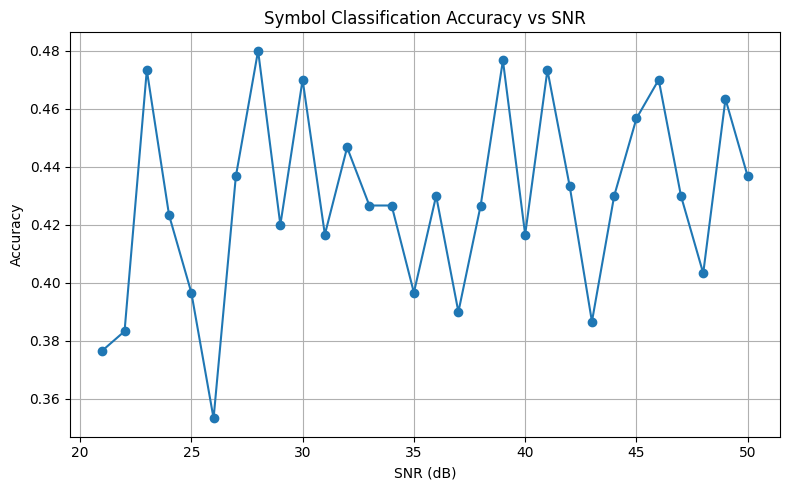

In [4]:
with open("evaluation_results.json", "r") as f:
    data_final = json.load(f)
# Convert SNR keys back to int
data_final = {int(k): v for k, v in data_final.items()}
print(data_final)
snrs = sorted(data_final.keys())
print(snrs)
accuracy = []

for snr in snrs:
    correct = data_final[snr]["correct"]
    total = correct + data_final[snr]["false"]
    accuracy.append(correct / total)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(snrs, accuracy, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Symbol Classification Accuracy vs SNR")
plt.grid(True)
plt.gca()
plt.tight_layout()
plt.show()